In [1]:
# Chunk 1: Load engineered data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Data/Engineered/Engineered.csv")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (2000, 28)

First 5 rows:
   rsrp_min  rsrp_max  rsrp_mean  rsrp_std  rsrp_last  rsrp_slope_last5  \
0     -86.3     -68.0 -79.745902  4.866586      -84.0             -0.03   
1     -80.5     -64.5 -73.235043  4.846056      -76.9              0.59   
2     -78.2     -65.3 -70.996226  3.055414      -71.7             -0.41   
3     -74.1     -68.6 -71.117949  1.302603      -73.4             -0.27   
4     -88.2     -71.6 -81.428636  4.294687      -83.2              1.02   

   rsrp_slope_all  rsrp_time_below_minus110  rsrq_min  rsrq_mean  ...  \
0       -0.121795                         0     -14.8  -8.442623  ...   
1       -0.061442                         0     -16.0  -8.335043  ...   
2        0.020717                         0     -16.8  -8.412579  ...   
3       -0.061822                         0     -16.4  -8.253846  ...   
4       -0.048682                         0     -18.0  -9.246818  ...   

   tower_load_max  tower_load_high  speed_kmph_mean  speed_kmph_max  

In [2]:
# Chunk 2: Data types, missing values, memory usage
print("\n--- Data Types ---")
print(df.dtypes.value_counts())

print("\n--- Missing Values ---")
print(df.isnull().sum().sum(), "total missing values")

print("\n--- Descriptive Stats ---")
display(df.describe())


--- Data Types ---
float64    18
int64      10
Name: count, dtype: int64

--- Missing Values ---
0 total missing values

--- Descriptive Stats ---


,rsrp_min,rsrp_max,rsrp_mean,rsrp_std,rsrp_last,rsrp_slope_last5,rsrp_slope_all,rsrp_time_below_minus110,rsrq_min,rsrq_mean,...,tower_load_max,tower_load_high,speed_kmph_mean,speed_kmph_max,call_duration_sec,start_hour,band_5G_n78,band_LTE_B20,band_LTE_B3,is_drop
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,-90.567750,-71.469950,-79.196703,4.759519,-85.98880,-0.090225,-0.127901,0.941000,-16.69980,-8.959413,...,52.720000,12.206000,21.340150,21.340150,128.666500,10.908000,0.327500,0.335500,0.337000,0.070000
std,14.428708,7.866183,8.761954,3.243063,15.45809,0.817872,0.356816,3.529837,1.59765,0.893397,...,20.233717,40.953524,32.451789,32.451789,63.283384,7.341286,0.469419,0.472283,0.472803,0.255211
min,-132.000000,-96.000000,-112.793333,0.814916,-128.00000,-9.870000,-5.644242,0.000000,-20.00000,-12.890909,...,10.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-97.700000,-77.300000,-84.889493,2.545167,-94.70000,-0.390000,-0.126729,0.000000,-17.80000,-9.538768,...,37.000000,0.000000,2.800000,2.800000,72.750000,4.000000,0.000000,0.000000,0.000000,0.000000
50%,-87.200000,-71.500000,-78.809028,3.736416,-83.65000,-0.070000,-0.057830,0.000000,-16.60000,-8.932225,...,51.000000,0.000000,5.700000,5.700000,127.000000,10.500000,0.000000,0.000000,0.000000,0.000000
75%,-79.800000,-66.300000,-73.096526,5.920809,-75.00000,0.280000,-0.003163,0.000000,-15.60000,-8.324130,...,67.000000,0.000000,9.900000,9.900000,184.000000,17.000000,1.000000,1.000000,1.000000,0.000000
max,-65.400000,-44.000000,-53.770000,20.453484,-44.00000,3.500000,0.251162,57.000000,-11.50000,-6.620476,...,100.000000,239.000000,119.900000,119.900000,238.000000,23.000000,1.000000,1.000000,1.000000,1.000000


Target distribution:
is_drop
0    1860
1     140
Name: count, dtype: int64

Percentages:
is_drop
0    93.0
1     7.0
Name: proportion, dtype: float64


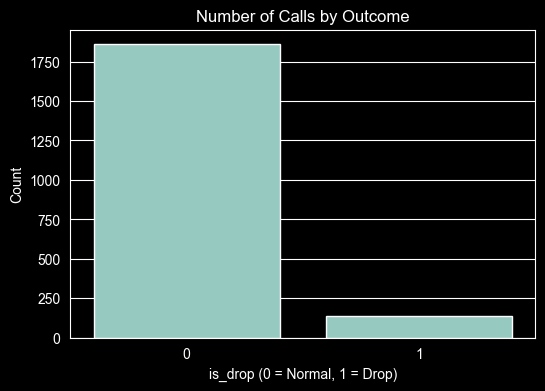

In [3]:
# Chunk 3: Check class imbalance
target_counts = df['is_drop'].value_counts()
target_perc = df['is_drop'].value_counts(normalize=True) * 100

print("Target distribution:")
print(target_counts)
print("\nPercentages:")
print(target_perc)

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x='is_drop', data=df)
plt.title('Number of Calls by Outcome')
plt.xlabel('is_drop (0 = Normal, 1 = Drop)')
plt.ylabel('Count')
plt.show()

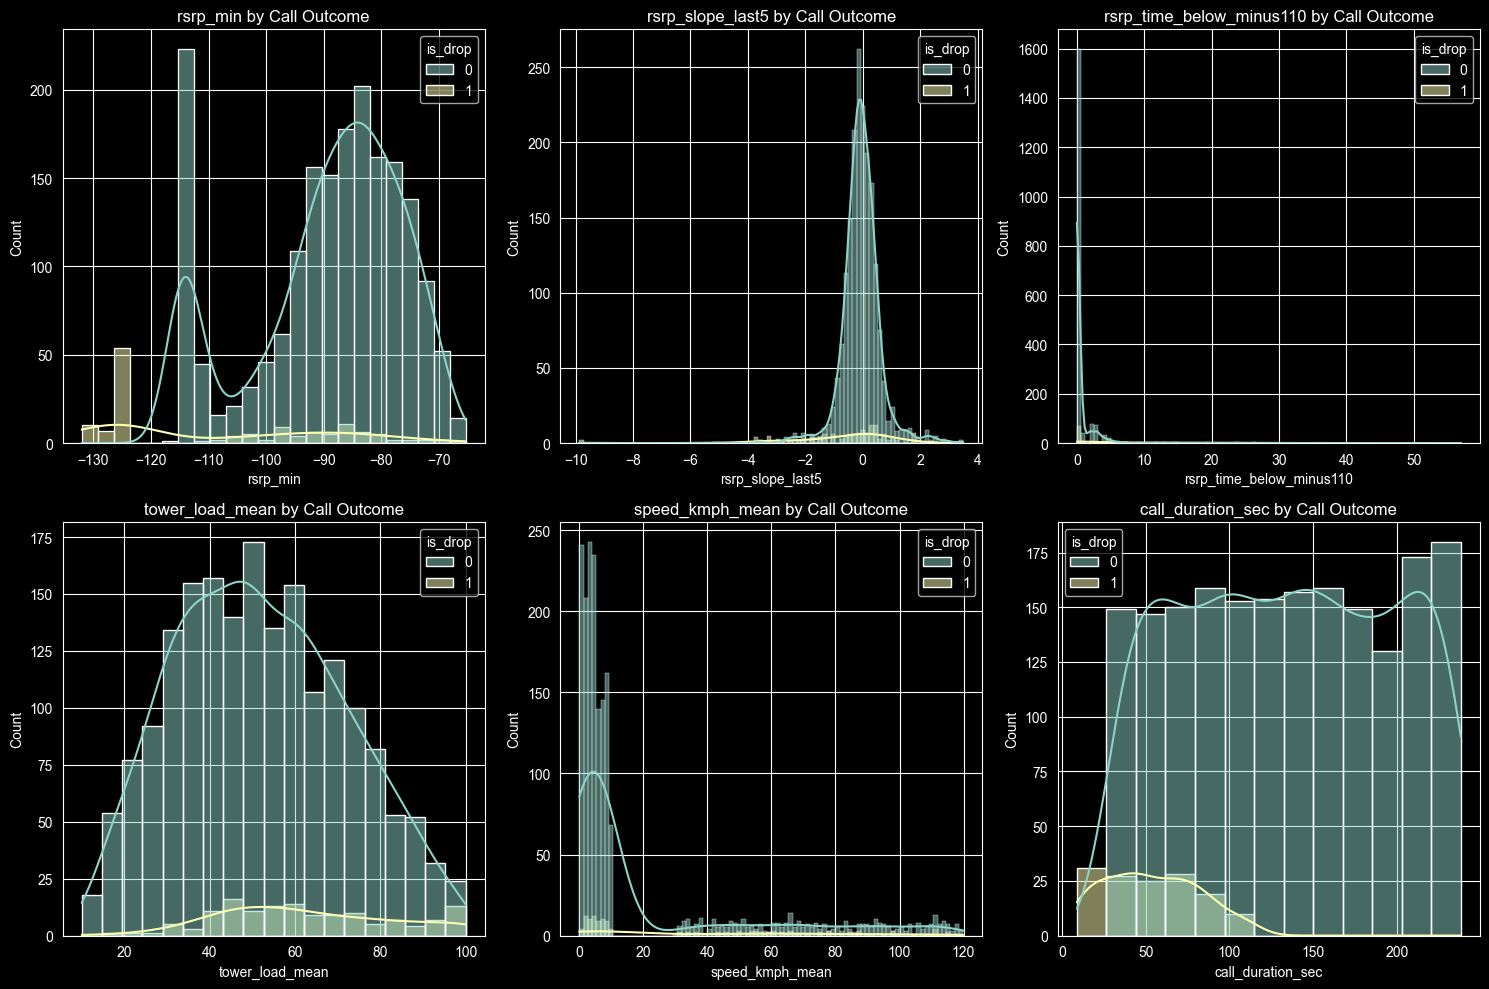

In [4]:
# Chunk 4: Compare feature distributions for dropped vs normal calls
# Select a few key numeric features (adjust list as needed)
key_features = ['rsrp_min', 'rsrp_slope_last5', 'rsrp_time_below_minus110',
                'tower_load_mean', 'speed_kmph_mean', 'call_duration_sec']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.histplot(data=df, x=feat, hue='is_drop', kde=True, ax=axes[i])
    axes[i].set_title(f'{feat} by Call Outcome')
plt.tight_layout()
plt.show()

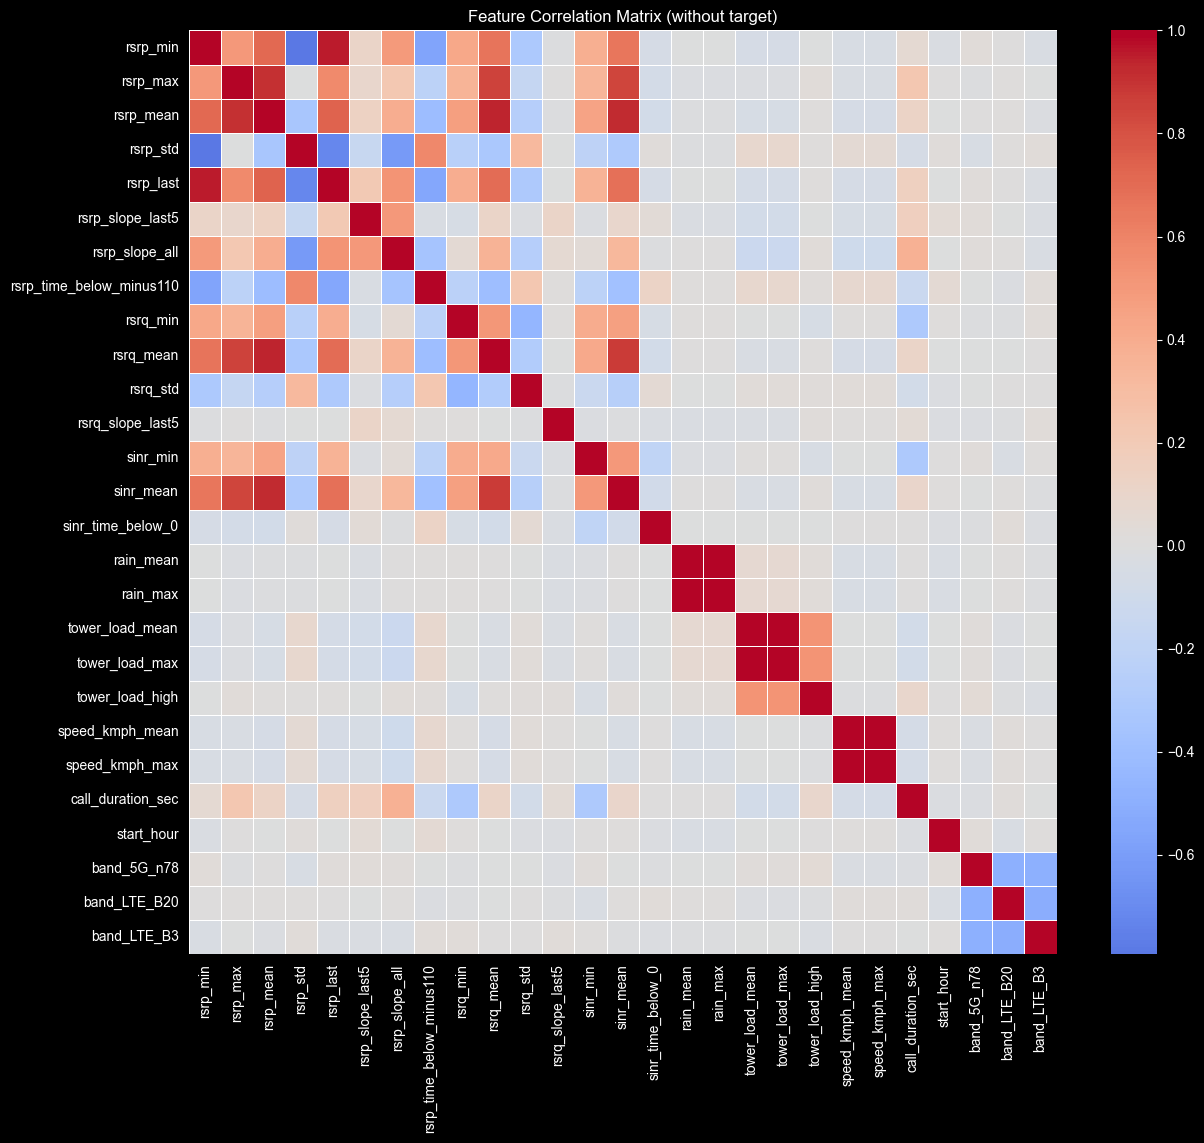

Highly correlated feature pairs (|corr| > 0.8):
  rsrp_min vs rsrp_last: 0.953
  rsrp_max vs rsrp_mean: 0.904
  rsrp_max vs rsrq_mean: 0.846
  rsrp_max vs sinr_mean: 0.844
  rsrp_mean vs rsrp_max: 0.904
  rsrp_mean vs rsrq_mean: 0.940
  rsrp_mean vs sinr_mean: 0.929
  rsrp_last vs rsrp_min: 0.953
  rsrq_mean vs rsrp_max: 0.846
  rsrq_mean vs rsrp_mean: 0.940


In [5]:
# Chunk 5: Correlation among features (excluding target)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('is_drop')   # remove target for correlation matrix

corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix (without target)')
plt.show()

# Show features highly correlated with each other (>0.8)
high_corr = (corr.abs() > 0.8) & (corr != 1.0)
high_corr_pairs = [(col, row_idx) for col in high_corr.columns for row_idx in high_corr.index if high_corr.loc[row_idx, col] and row_idx != col]
print("Highly correlated feature pairs (|corr| > 0.8):")
for pair in high_corr_pairs[:10]:
    print(f"  {pair[0]} vs {pair[1]}: {corr.loc[pair[1], pair[0]]:.3f}")


Top 10 most important features (Random Forest):
1. rsrp_min: 0.1640
2. rsrp_last: 0.1344
3. rsrp_slope_all: 0.1038
4. call_duration_sec: 0.0927
5. rsrp_mean: 0.0550
6. rsrp_std: 0.0492
7. rsrp_max: 0.0486
8. sinr_mean: 0.0411
9. rsrq_mean: 0.0388
10. rsrp_time_below_minus110: 0.0369


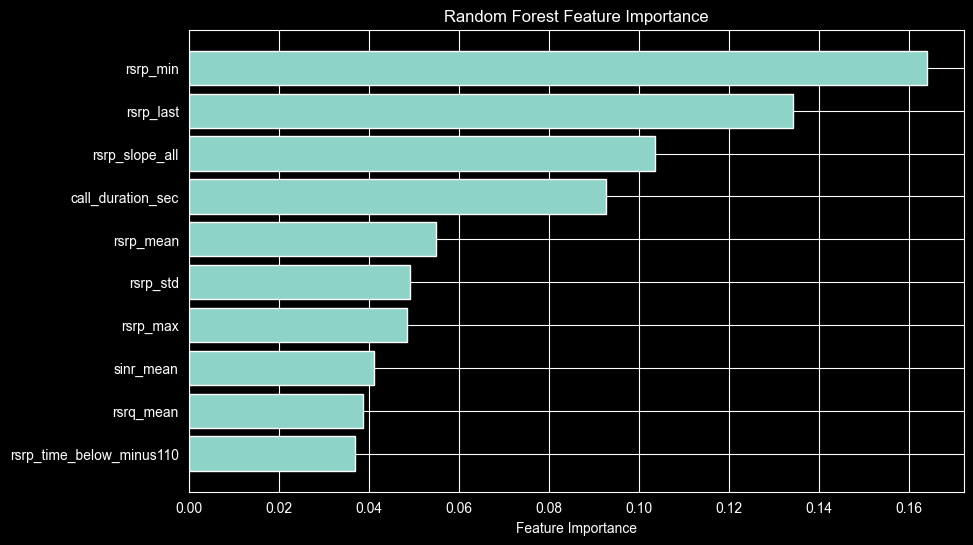

In [6]:
# Chunk 6: Quick feature importance (Random Forest)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

X = df.drop('is_drop', axis=1)
y = df['is_drop']

# Scale (optional for tree models, but good for comparison)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_scaled, y)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nTop 10 most important features (Random Forest):")
for i in range(10):
    print(f"{i+1}. {X.columns[indices[i]]}: {importances[indices[i]]:.4f}")

# Plot
plt.figure(figsize=(10,6))
plt.barh(range(10), importances[indices[:10]][::-1])
plt.yticks(range(10), [X.columns[i] for i in indices[:10]][::-1])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()

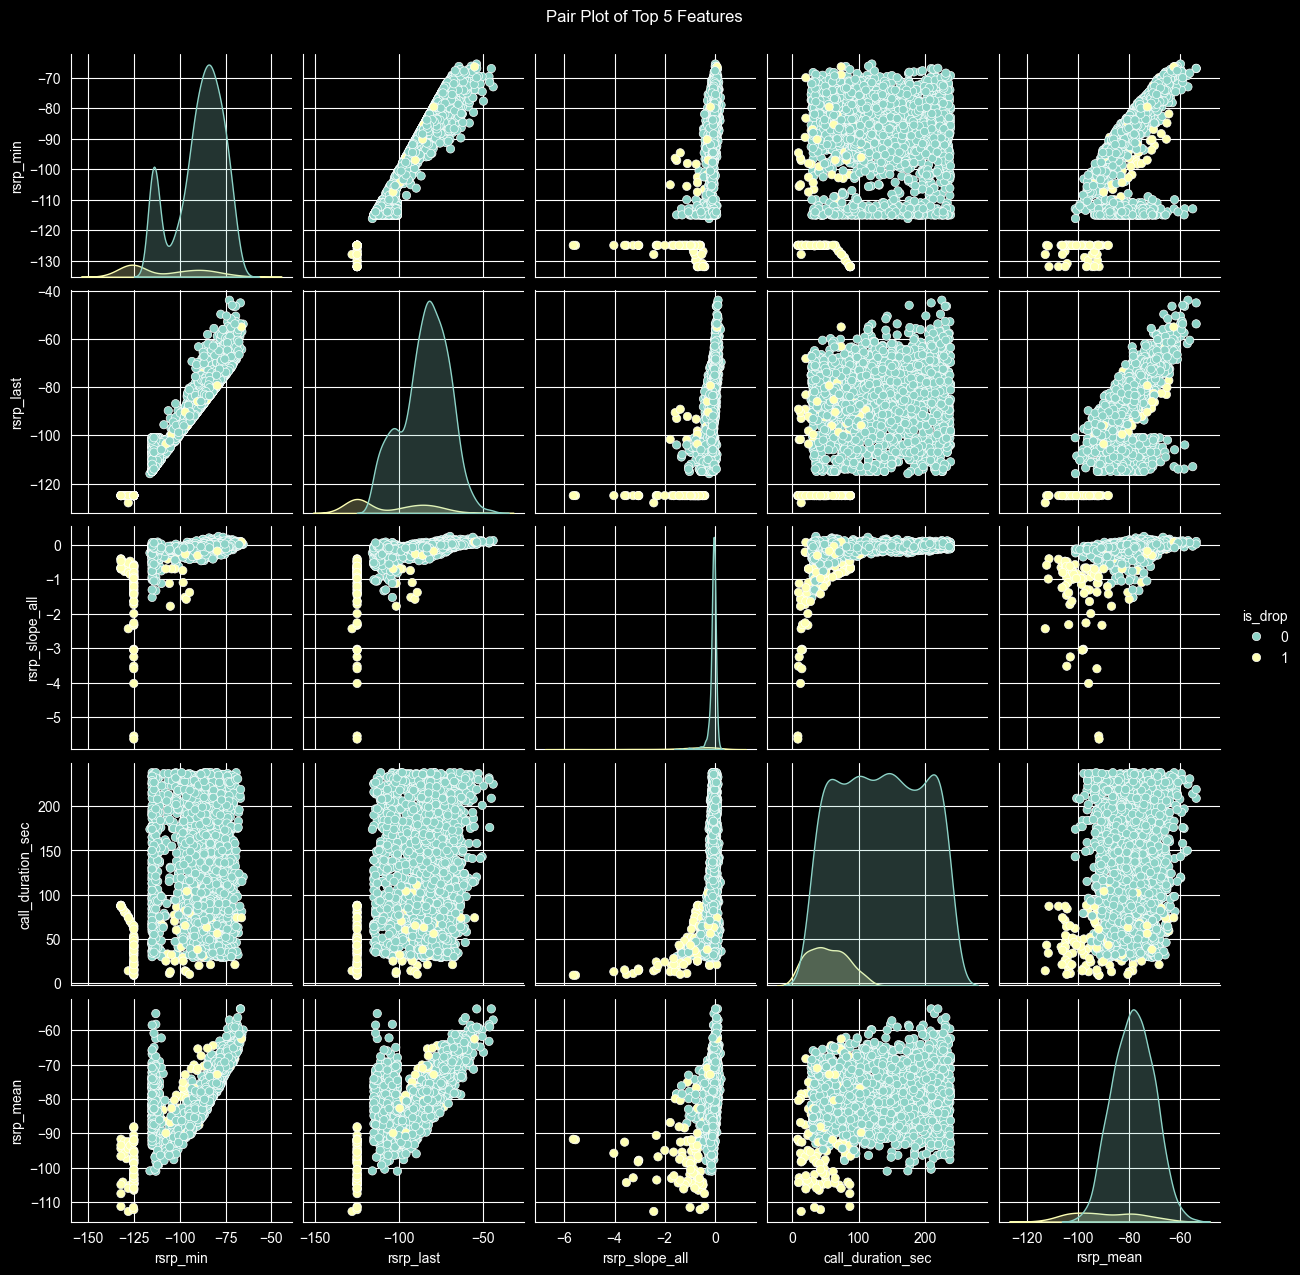

In [7]:
# Chunk 7: Pair plot of the most important features (avoid too many)
top_feats = [X.columns[indices[i]] for i in range(5)] + ['is_drop']
sns.pairplot(df[top_feats], hue='is_drop', diag_kind='kde')
plt.suptitle('Pair Plot of Top 5 Features', y=1.02)
plt.show()